# Generate figures for Supplemental Information
<br>

**Author:** Jack Logan

This notebook generates the figures and movies found in the supplemental information.
These figures include velocity uncertainty estimation, fracture confidence and velocity movies, a velocity of parcel advection.

### Import Packages

In [1]:
import cmocean.cm as ccm
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from IPython.display import Image, Video
from matplotlib.ticker import FuncFormatter
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.colors import Normalize

import blue_ice_tools as bit

# . . Matplotlib initializations
plt.rcParams.update({  # Font parameters
    "mathtext.fontset": "dejavuserif",
    "font.family": "serif",
    "font.size":14,
})
FFwriter = FFMpegWriter()  # Movie writer

## Load Datasets

In [2]:
# . . NetCDF datasets
velocity_ds = xr.open_dataset('data/velocity.nc')
snr_da = xr.open_dataset(
    's3://nasa-cryo-persistent/netcdf-sar-data/dense_offsets_snr_100m.nc', engine='h5netcdf'
).squeeze(drop=True)['band_data']
fracture_da = xr.open_dataset('data/shirase-fracture-sorted.nc', decode_coords='all')['fracture_conf']
img_da = xr.open_dataarray('./data/landsat_rgb.nc')

# . . Parcel Datasets
parcels_singlecrev = xr.open_dataset('./data/parcel-timeseries-singlecrev.nc')
parcels_unrelated  = xr.open_dataset('./data/parcel-timeseries-unrelated.nc')
parcel_ensemble    = xr.open_dataset('./data/parcel-ensemble.nc')

# . . Shapefiles
shirase_shape = gpd.read_file('./data/shapefiles/shirase.shp')
grounding_line = gpd.read_file('./data/shapefiles/RINGS_grounded_2022_polyline.shp')

## Uncertainty Figures

### Calculate Uncertainty

Uncertaintly as percent error, calculate by dividing the velocity at a cell by its SNR.

In [3]:
# . . Select one day for plots
vel = velocity_ds.isel(mid_date=0)
snr = snr_da.isel(mid_date=0)

# . . Calculate percent uncertainty
uncertainty = vel / snr
percent_uncertainty = (np.abs(uncertainty) / np.abs(vel)) * 100

### Figure S1: Percent Uncertainty

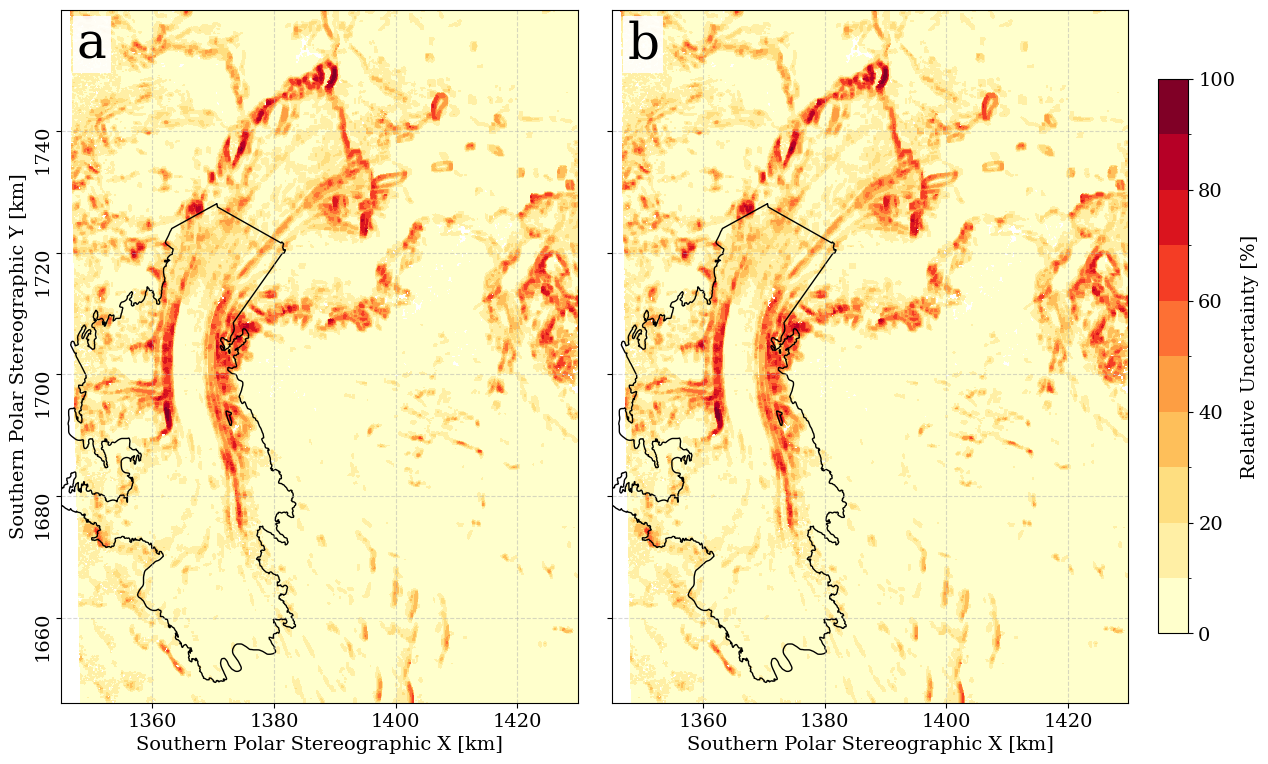

In [4]:
# . . Generate figure
fig, axs = plt.subplots(1, 2, figsize=(15,9))
ax1, ax2 = axs

percent_uncertainty['vx'].plot.contourf(
    ax=ax1, 
    levels=11, 
    vmin=0, vmax=100, 
    cmap='YlOrRd', 
    add_colorbar=False
)
qm = percent_uncertainty['vy'].plot.contourf(
    ax=ax2, 
    levels=11, 
    vmin=0, vmax=100, 
    cmap='YlOrRd', 
    add_colorbar=False
)

letters = list('ab')
for i, ax in enumerate(axs):
    shirase_shape.plot(ax=ax, facecolor='none')

    ax.set_xlim(snr.x.min(), snr.x.max())
    bit.format_map(ax)
    bit.map_patch(ax, letters[i])

ax2.set_ylabel(None)
ax2.set_yticklabels([])

plt.subplots_adjust(wspace=-0.1)

pos = ax.get_position()
y0 = pos.y0
height = pos.height
buff = height * 0.1

cax = fig.add_axes([pos.x1+0.02, pos.y0+buff, 0.02, height-2*buff])
cbar = fig.colorbar(qm, cax=cax, shrink=0.8, label='Relative Uncertainty [%]')

plt.savefig('./media/supplemental/s01-percent-error.png', bbox_inches='tight')
plt.show()

### Figure S2: Uncertainty over 30%

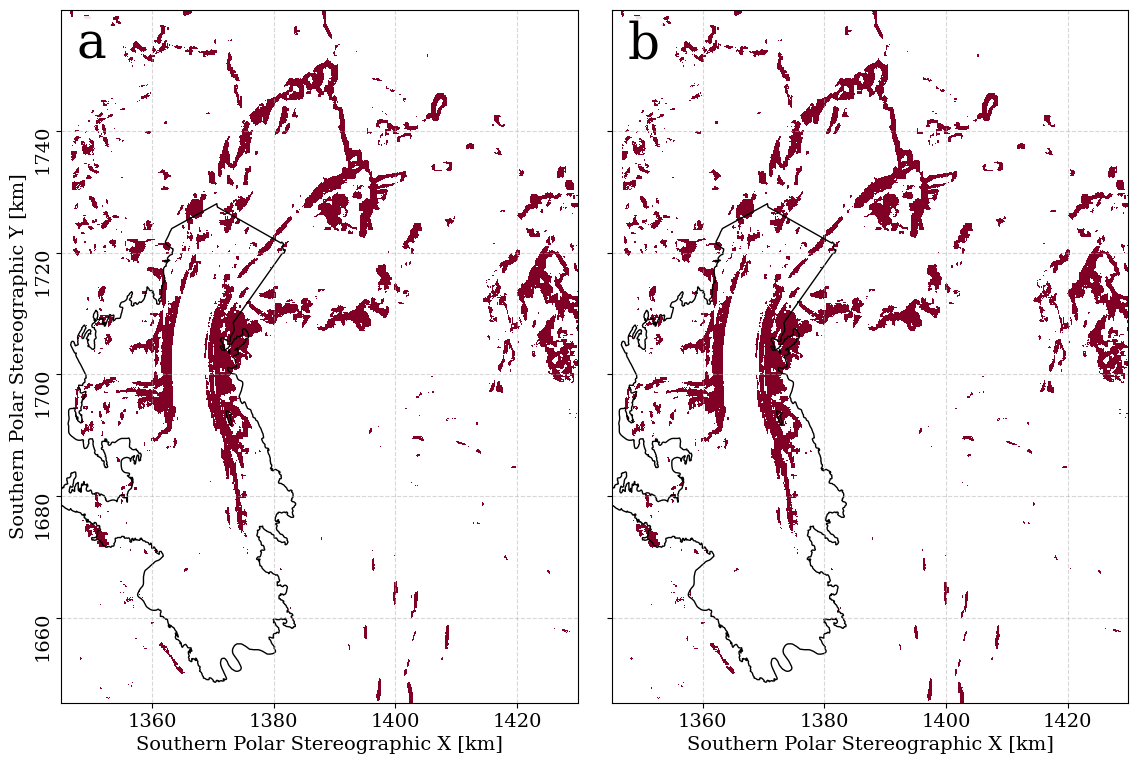

In [5]:
large_err = percent_uncertainty.where(percent_uncertainty > 30)

fig, axs = plt.subplots(1, 2, figsize=(15, 9))
ax1, ax2 = axs 

large_err['vx'].plot(
    ax=ax1, 
    levels=1, 
    vmin=0, vmax=100, 
    cmap='YlOrRd', 
    add_colorbar=False
)
qm = large_err['vy'].plot(
    ax=ax2, 
    levels=1, 
    vmin=0, vmax=100, 
    cmap='YlOrRd', 
    add_colorbar=False
)

letters = list('ab')
for i, ax in enumerate(axs):
    shirase_shape.plot(ax=ax, facecolor='none')

    ax.set_xlim(snr.x.min(), snr.x.max())
    bit.format_map(ax)
    bit.map_patch(ax, letters[i])

ax2.set_ylabel(None)
ax2.set_yticklabels([])

plt.subplots_adjust(wspace=-0.1)

plt.savefig('./media/supplemental/s02-high-error.png', bbox_inches='tight')
plt.show()

## Fracture Confidence

### Figure S3: CNN Validation

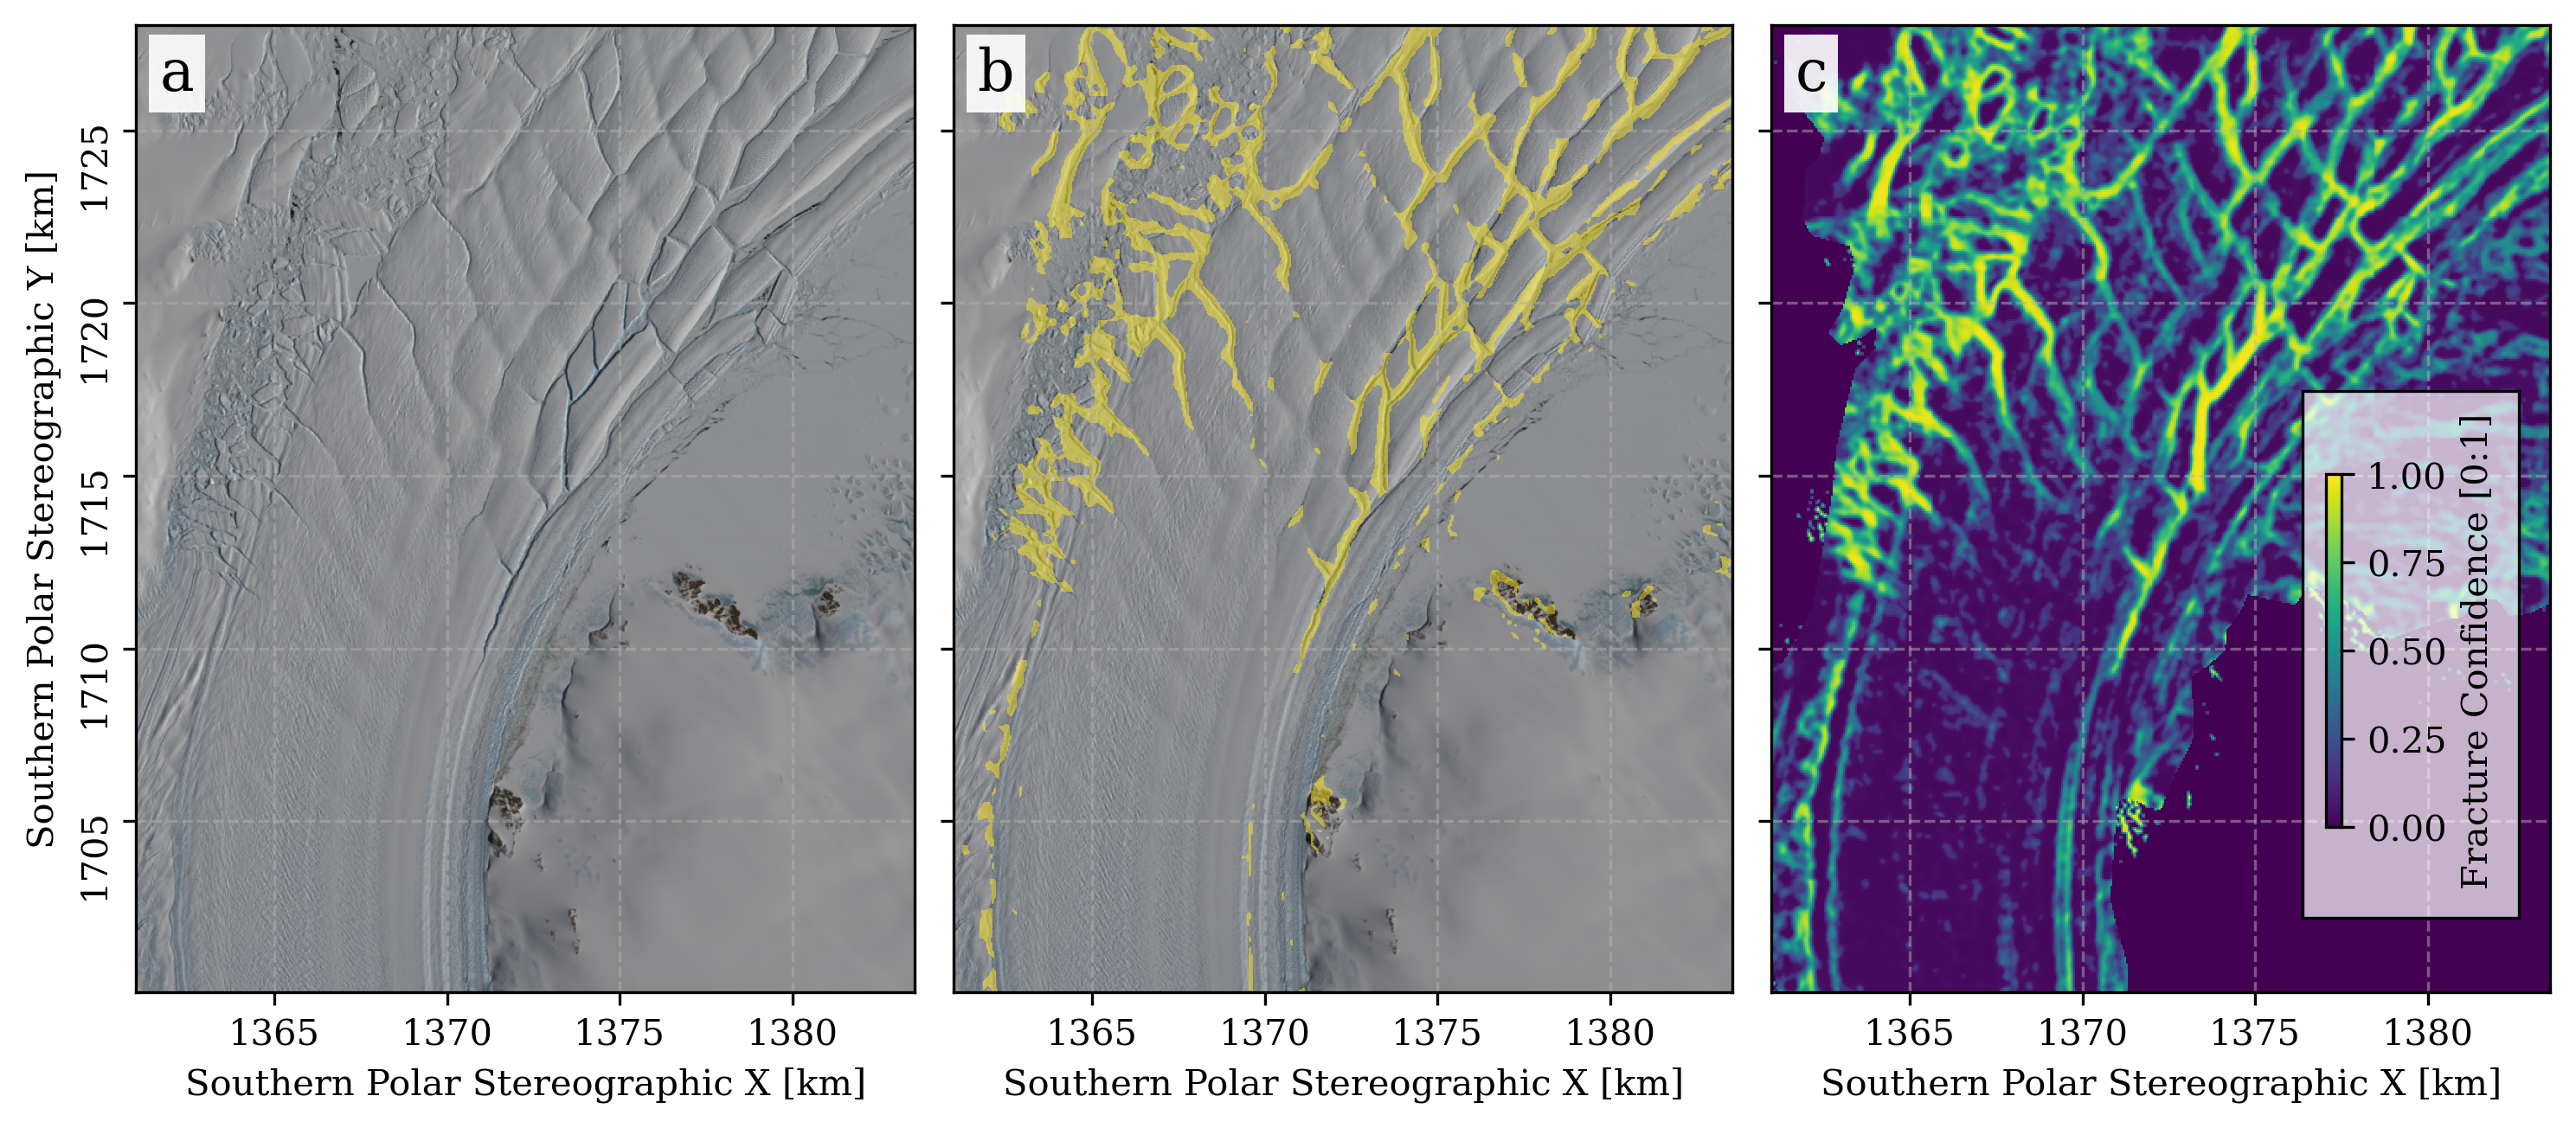

In [6]:
plt.rcParams.update({"font.size":10})

# . . Get data for plotting scene
img = img_da.transpose("y", "x", "band").values
x0, x1 = float(img_da.x.min()), float(img_da.x.max())
y0, y1 = float(img_da.y.min()), float(img_da.y.max())

frac = fracture_da.sel(mid_date='2022-12-13', method='bfill')

# . . Generate Figure
fig, axs = plt.subplots(1, 3, figsize=(12,12), dpi=300)
ax1, ax2, ax3 = axs

# Plot Landsat-8 image as RGB
extent = [x0, x1, y0, y1]  # [xmin, xmax, ymin, ymax]
ax1.imshow(img, extent=extent, origin='lower', zorder=0)
ax2.imshow(img, extent=extent, origin='lower', zorder=0)

# Fracture threshold
qm1 = frac.where(frac>0.6).plot.contourf(
    ax=ax2, alpha=0.5, levels=[0.6, 1], add_colorbar=False,
    cmap='viridis_r'
)

# Fracture confidence map
qm2 = frac.plot(
    ax=ax3, vmin=0, vmax=1, add_colorbar=False
)

# Format map
letters = 'abc'
for ax, letter in zip(axs, letters):
    bit.format_map(ax, fs=10)
    bit.map_patch(ax, letter, fs=16)
    ax.set_ylim(1700050, 1728050)
    ax.set_xlim(1361000, 1383550)

# remove redundant tickmarks
for ax in axs[1:]:
    ax.set_yticklabels([])
    ax.set_ylabel(None)

# Inset colorbar
bit.inset_colorbar(
    fig, ax3, qm2, 'Fracture Confidence [0:1]',
    inset=0.01, pad=0.015
)

# Adjust subplot spacing, save figure
plt.subplots_adjust(wspace=0.05)
plt.savefig('./media/supplemental/s03-cnn-validation.png', bbox_inches='tight')
plt.show()

## Parcel Figures

### Figure S4: Initial Parcel Selection (unrelated parcels)

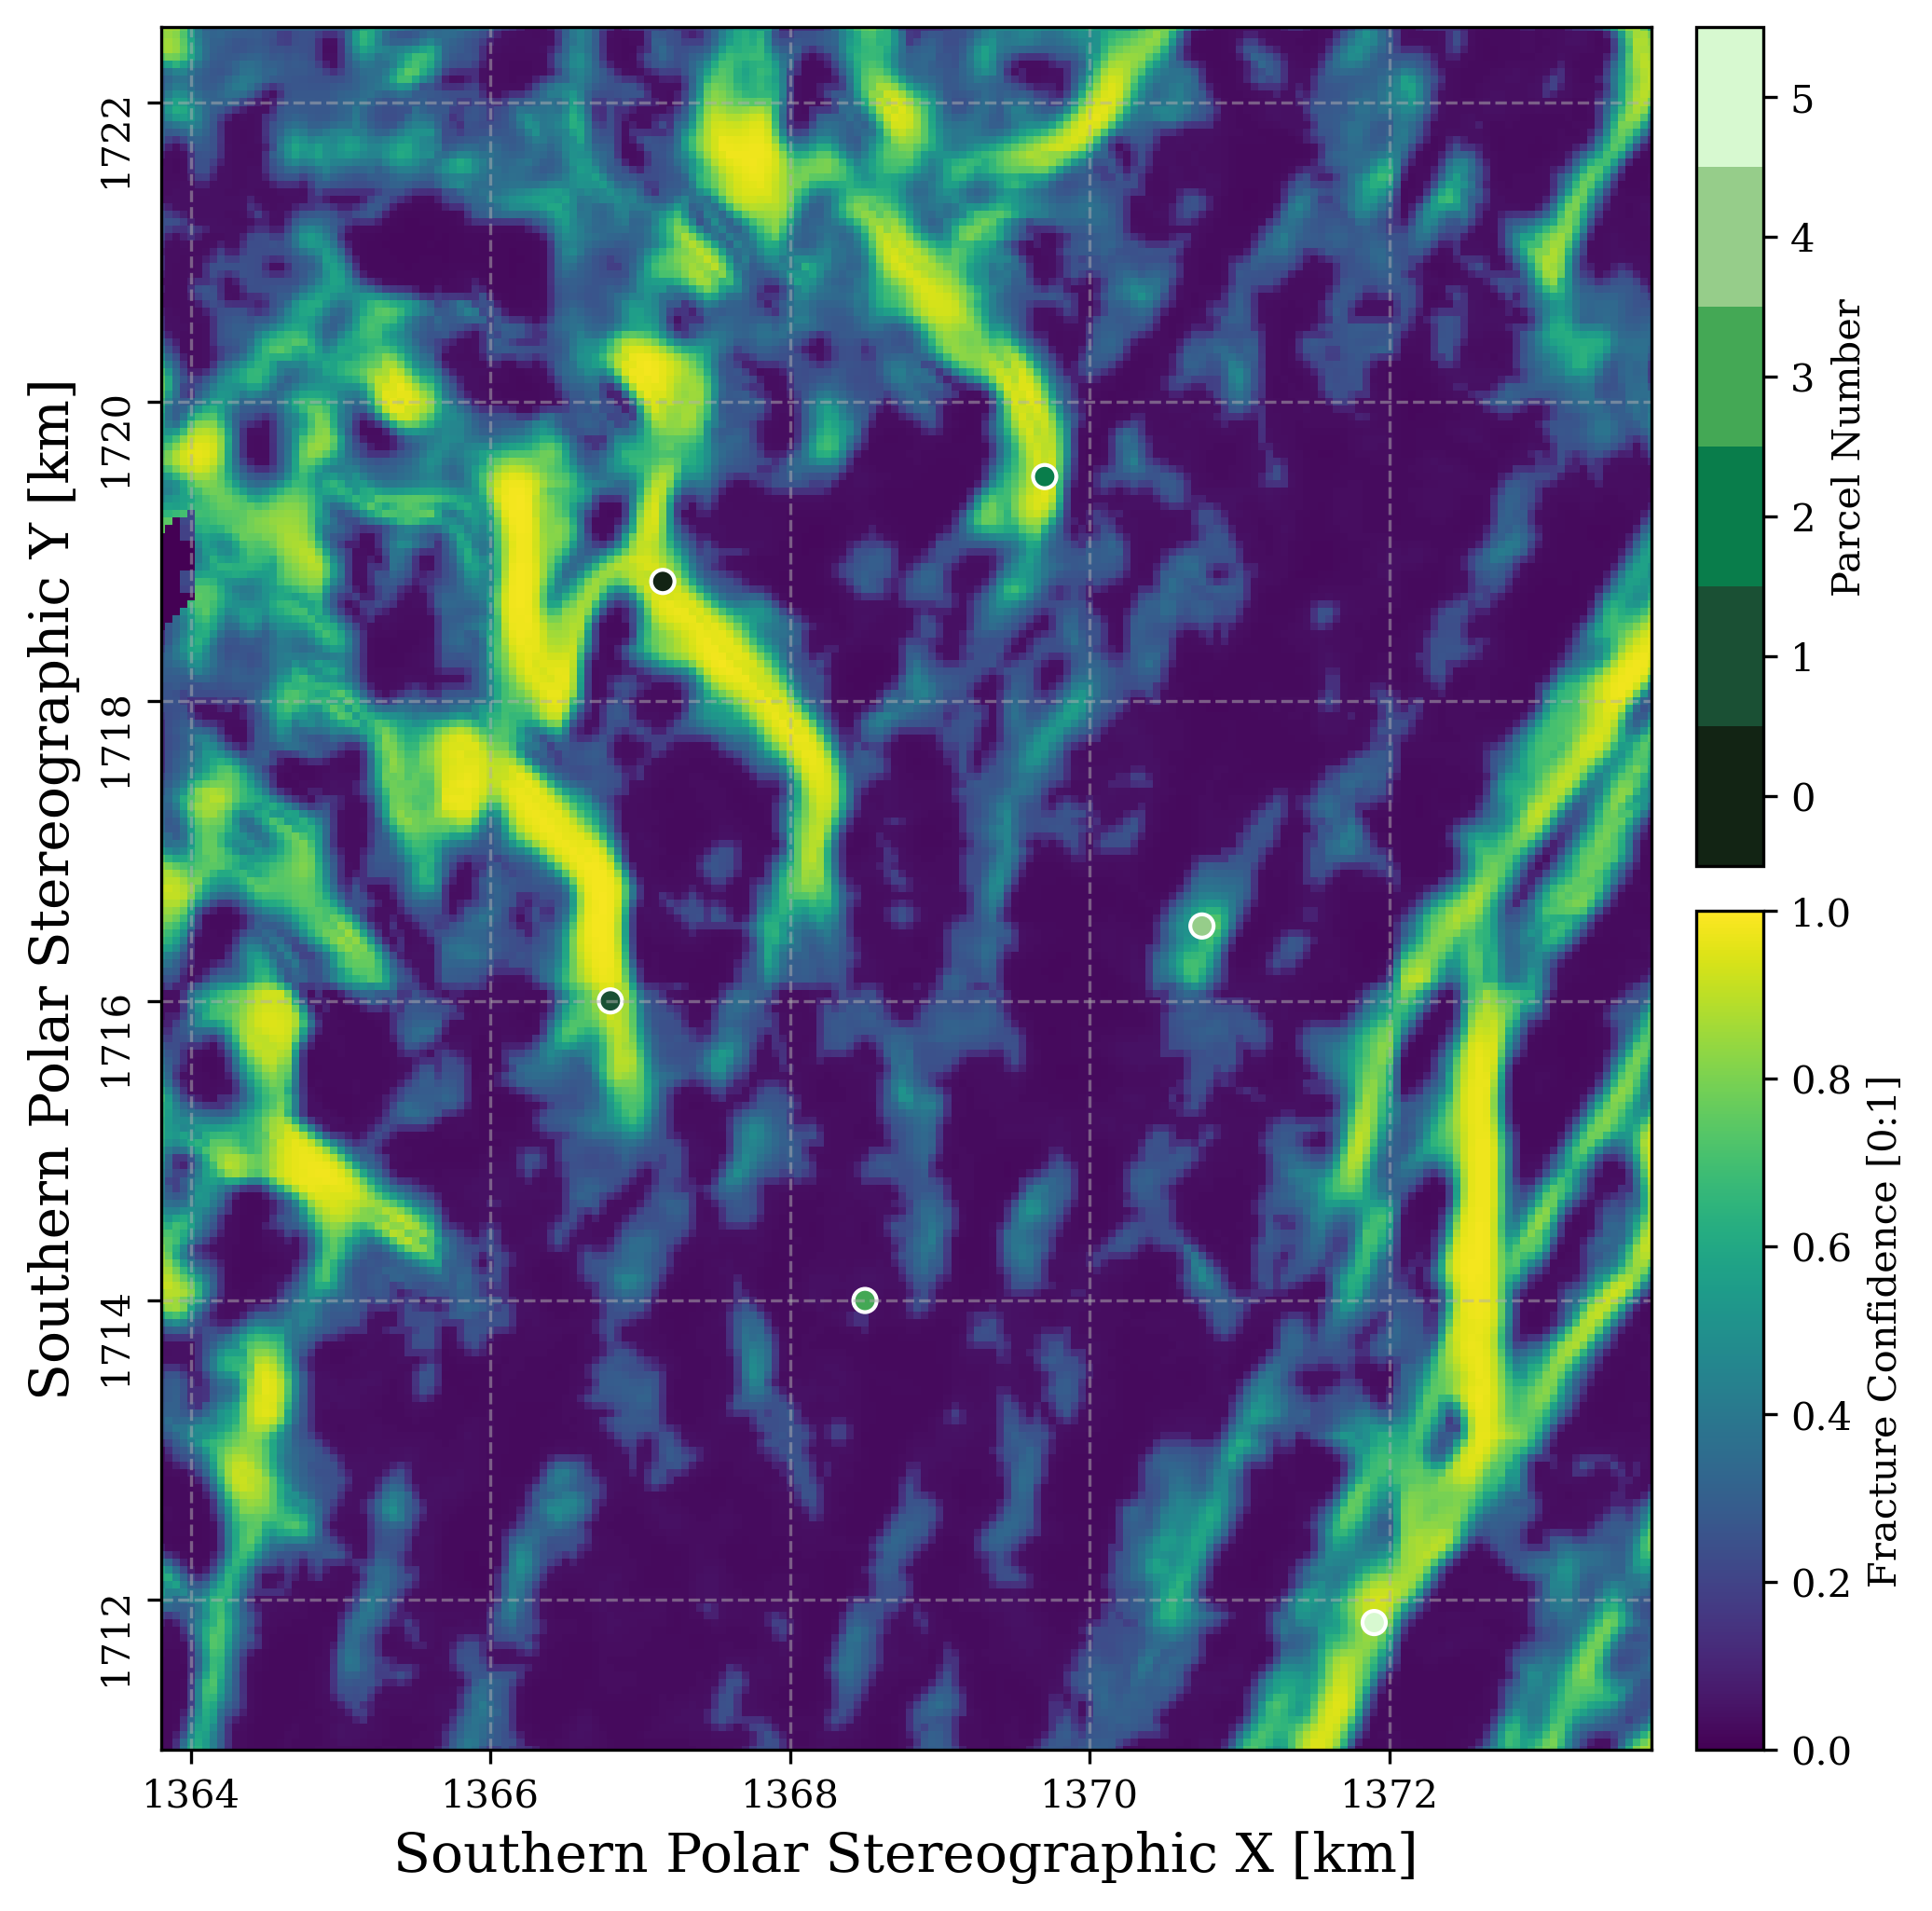

In [7]:
n_parcels = len(parcels_unrelated.parcel)
levels = [i-0.5 for i in range(n_parcels+1)]

fig, ax = plt.subplots(figsize=(8,8), dpi=300)

qm = fracture_da.sel(mid_date='2022-03-25', method='bfill').plot(
    ax=ax, vmin=0, vmax=1, add_colorbar=False
)

cs = parcels_unrelated.sel(mid_date='2022-03-25').plot.scatter(
    x='x', y='y', hue='parcel',
    ax=ax, cmap=ccm.algae_r,
    levels=levels,
    add_colorbar=False
)

ax.set_xlim(1363800.0, 1373750.0)
ax.set_ylim(1711000.0, 1722500.0)
bit.format_map(ax)

pos = ax.get_position()

# Compute new position spanning ax1 to ax2
x1 = pos.x1
y0 = pos.y0
y1 = pos.y1
width = 0.03
wspace = 0.02
height = (y1 - y0) / 2 - 0.01

cax1 = fig.add_axes([
    x1+wspace,
    y0,
    width,
    height
])

cax2 = fig.add_axes([
    x1+wspace,
    y1-height,
    width,
    height
])

cbar1 = fig.colorbar(
    qm, cax=cax1,
    label='Fracture Confidence [0:1]'
)
cbar2 = fig.colorbar(
    cs, cax=cax2, 
    label='Parcel Number', ticks=[i for i in range(n_parcels)]
)
cbar2.ax.yaxis.minorticks_off()

plt.savefig('./media/supplemental/s04-parcel-selection.png', bbox_inches='tight')
plt.show()
plt.close()

### Figure S5: Initial Parcel Selection (ensemble)

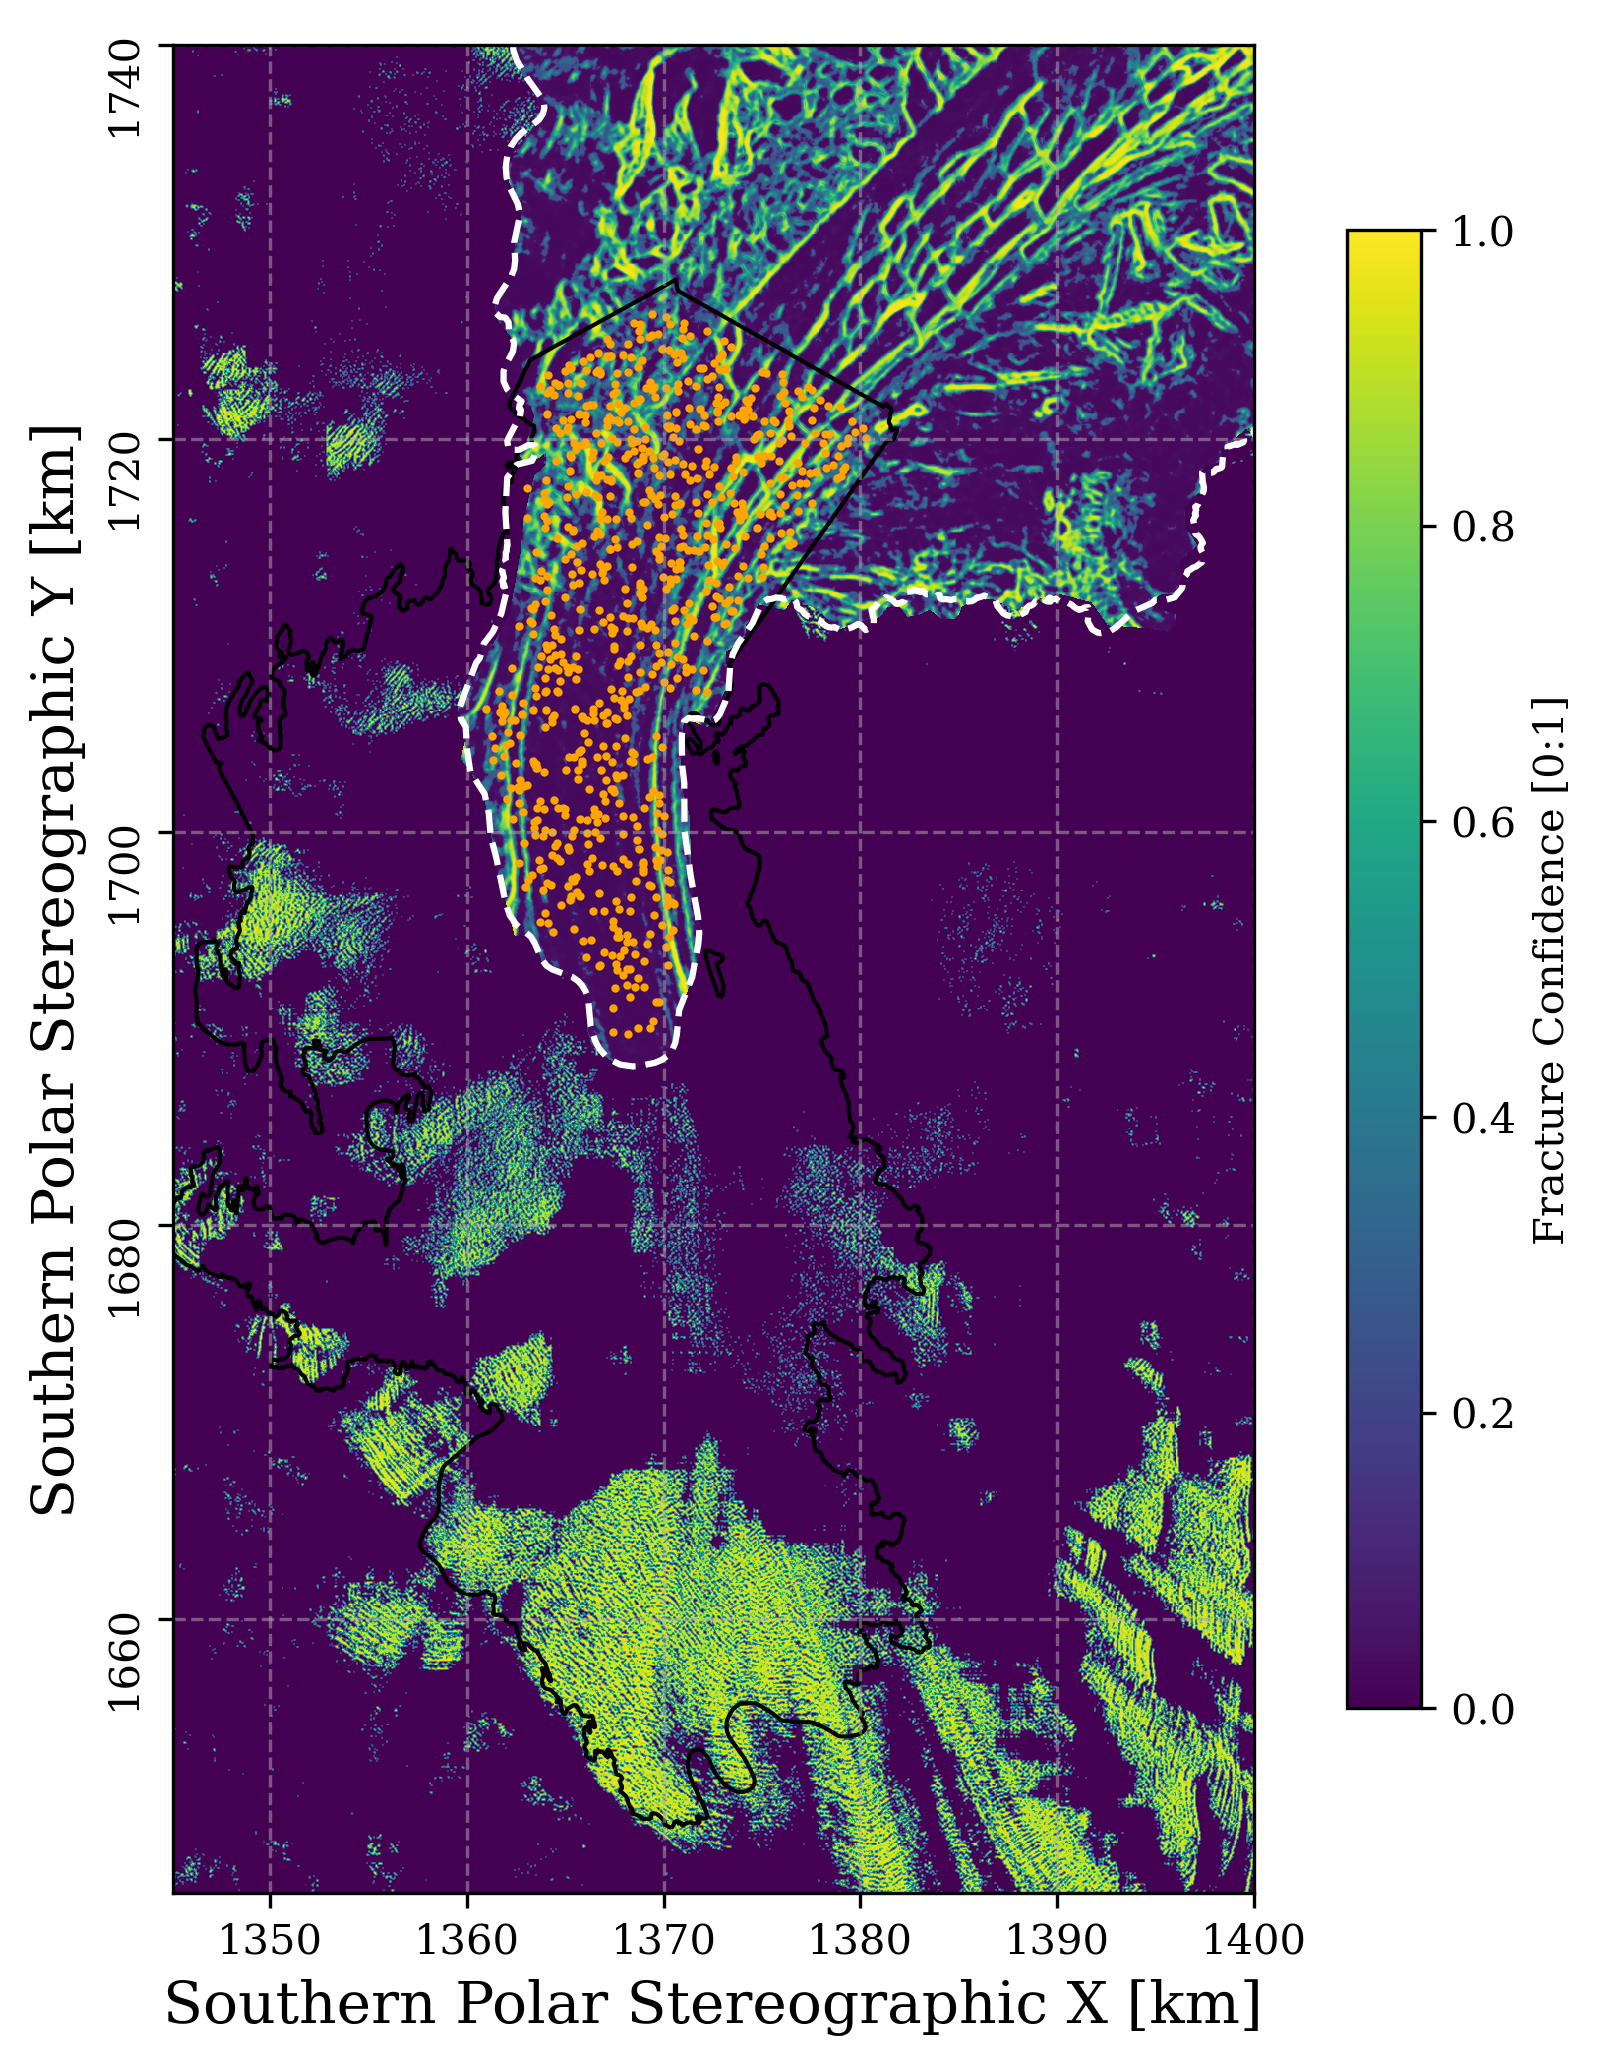

In [8]:
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

qm = fracture_da.sel(mid_date='2022-03-25', method='bfill').plot(
    ax=ax, vmin=0, vmax=1, 
    cbar_kwargs={'shrink': 0.8, 'label': 'Fracture Confidence [0:1]'}
)

cs = parcel_ensemble.sel(mid_date='2022-03-25').plot.scatter(
    x='x', y='y',
    ax=ax, color='orange',
    s=1,
    add_colorbar=False
)

shirase_shape.plot(ax=ax, facecolor='none', ec='k')
grounding_line.plot(ax=ax, facecolor='none', ec='w', ls='--')

ax.set_xlim(fracture_da.x.min(), 1.4e6)
ax.set_ylim(fracture_da.y.min(), 1.74e6)
bit.format_map(ax)

# plt.savefig('./media/supplemental/s04-parcel-selection.png', bbox_inches='tight')
plt.show()
plt.close()

## Movies

### MS01: Fracture Confidence Timeseries

In [9]:
# . . Find gif interval for gif length and number of frames
total_time = 10000  # Length of gifs in ms (10 s)
frames = len(fracture_da.mid_date)
interval = total_time / frames

# . . Initialize plot
fig, ax = plt.subplots(1, 1, figsize=(9,9))

# Fix the colorbar scale (vmin/vmax) so it doesn't jump between frames
im1 = fracture_da.isel(mid_date=0).plot(
    ax=ax, vmin=fracture_da.min(), vmax=fracture_da.max(),
    cmap='viridis',
    cbar_kwargs={'label':'Fracture Confidence [0:1]', 'shrink':0.8}
)
shirase_shape.plot(ax=ax, facecolor='none')

bit.format_map(ax)

def update(frame):
    # Update the data of the existing plot object
    im1.set_array(fracture_da.isel(mid_date=frame).values.flatten())

    ax.set_title(f"Time: {str(fracture_da.mid_date.values[frame])[:10]}")    
    return im1,

# . . Make the GIF
frac_ani = FuncAnimation(
    fig, update, frames=frames, interval=interval, blit=True
)
frac_ani.save('./media/supplemental/ms01.mp4', writer=FFwriter)
plt.close()

Video('./media/supplemental/ms01.mp4', embed=False)

### MS02: Velocity Timeseries

In [10]:
# Calculate interval using same total length
frames = len(velocity_ds.mid_date)
interval = total_time / frames

fig, ax = plt.subplots(1, 1, figsize=(9,9))

# Fix the colorbar scale (vmin/vmax) so it doesn't jump between frames
im1 = velocity_ds['vv'].isel(mid_date=0).plot(
    ax=ax, vmin=velocity_ds['vv'].min(), vmax=velocity_ds['vv'].max(), 
    cmap=ccm.dense_r, 
    cbar_kwargs={'label':'Velocity [m yr$^{-1}$]', 'shrink':0.8}
)

bit.format_map(ax)

def update(frame):
    # Update the data of the existing plot object
    im1.set_array(velocity_ds['vv'].isel(mid_date=frame).values.flatten())

    ax.set_title(f"Time: {str(velocity_ds.mid_date.values[frame])[:10]}")
    return im1,

ani = FuncAnimation(
    fig, update, frames=frames, interval=interval, blit=True
)

ani.save('./media/supplemental/ms02.mp4')
plt.close()

Video(filename='./media/supplemental/ms02.mp4', embed=False)

### MS03: Parcel Advection from Single Crevasse

In [11]:
def parcel_movie(parcels, fracture_da, savepath, cmap, total_time=2000, mode='single'):
    """
    Animate parcel advection trajectories overlaid on a fracture confidence background.

    Parameters
    ----------
    parcels : xr.Dataset
        Parcel dataset with dimensions (parcel, t) and coordinates 'x', 'y', 'mid_date',
        as returned by LagrangianTracking.parcel_advection or ensemble_advection.
    fracture_da : xr.DataArray
        Fracture confidence data with a 'mid_date' dimension, used as the background field.
    savepath : str
        Output path for the saved animation (e.g., './media/supplemental/ms03.mp4').
    cmap : matplotlib colormap
        Colormap used for parcel scatter in 'single' mode.
    total_time : int, optional
        Total animation duration in milliseconds. Default is 2000.
    mode : str, optional
        Scatter plotting mode:
        - 'single'   : parcels colored by parcel index using `cmap`.
        - 'ensemble' : all parcels plotted as uniform gray scatter.
        Default is 'single'.

    Returns
    -------
    None
        Animation is saved to `savepath` and the figure is closed.

    Notes
    -----
    - Fracture background is only re-rendered when the month changes, for efficiency.
    - The animation is saved using the globally defined `FFwriter`.
    - `shirase_shape` is expected in the enclosing scope.

    Examples
    --------
    >>> parcel_movie(parcels_singlecrev, fracture_da, './media/ms03.mp4', ccm.amp_i)
    >>> parcel_movie(ensemble_parcels,   fracture_da, './media/ms04.mp4', ccm.amp_i, mode='ensemble')
    """
    frames = len(parcels.t)
    interval = total_time / frames

    # . . Date matching
    parcel_dates = pd.DatetimeIndex(parcels.mid_date.values)
    fracture_dates = pd.DatetimeIndex(fracture_da.mid_date.values)

    parcel_ym = parcel_dates.to_period('M')
    fracture_ym = fracture_dates.to_period('M')

    fracture_indices = np.array([
        np.searchsorted(fracture_ym.asi8, pm.ordinal, side='right') - 1
        for pm in parcel_ym
    ])
    fracture_indices = np.clip(fracture_indices, 0, len(fracture_dates) - 1)

    # . . Create plot
    fig, ax = plt.subplots(figsize=(8, 8))

    # Static background
    im = fracture_da.isel(mid_date=0).plot(
        ax=ax,
        vmin=fracture_da.min(), vmax=fracture_da.max(),
        cmap='viridis',
        cbar_kwargs={'label': 'Fracture Confidence [0:1]', 'shrink': 0.6}
    )
    shirase_shape.plot(ax=ax, facecolor='none')
    grounding_line.plot(ax=ax, facecolor='none', ec='w', ls='--')

    # draw scatter for a given frame
    def draw_scatter(frame):
        snap = parcels.isel(t=frame)
        
        if mode == 'ensemble':
            # Flatten all parcels → plain gray scatter
            xs = snap.x.values.ravel()
            ys = snap.y.values.ravel()
            return snap.plot.scatter(
                x='x', y='y',
                ax=ax,
                c='grey', ec='none',
                s=4, add_colorbar=False
            )
        else:
            # Original: colored by parcel index
            n_parcels = len(parcels.parcel)
            levels = [i - 0.5 for i in range(n_parcels + 1)]
            return snap.plot.scatter(
                x='x', y='y', hue='parcel',
                cmap=cmap, ax=ax, ec='w',
                levels=levels, add_colorbar=False
            )

    scatter = draw_scatter(0)

    ax.set_xlim(parcels.x.min() - 4000, parcels.x.max() + 6000)
    ax.set_ylim(parcels.y.min() - 1000, parcels.y.max() + 1000)
    bit.format_map(ax)

    last_fracture_idx = [0]

    def update(frame):
        nonlocal scatter

        frac_idx = fracture_indices[frame]
        if frac_idx != last_fracture_idx[0]:
            im.set_array(fracture_da.isel(mid_date=frac_idx).values.ravel())
            last_fracture_idx[0] = frac_idx

        scatter.remove()
        scatter = draw_scatter(frame)
        bit.format_map(ax)
        ax.set_title(f"Date: {str(parcel_dates[frame])[:10]}")
        return im,

    ani = FuncAnimation(fig, update, frames=frames, interval=interval * 2, blit=True)
    ani.save(savepath, writer=FFwriter)
    plt.close()

parcel_movie(parcels_singlecrev, fracture_da, './media/supplemental/ms03.mp4', ccm.amp_i)
Video(filename='./media/supplemental/ms03.mp4', embed=False)

### MS04: Parcel Advection from Unrelated Points

In [12]:
parcel_movie(parcels_unrelated, fracture_da, './media/supplemental/ms04.mp4', ccm.algae_r)
Video(filename='./media/supplemental/ms04.mp4', embed=False)

### MS05: Parcel Ensemble movie

In [13]:
parcel_movie(parcel_ensemble, fracture_da, './media/supplemental/ms05.mp4', None, mode='ensemble')
Video(filename='./media/supplemental/ms05.mp4', embed=False)